# Уровень решения проблемы обработки и генерации естественного языка, ч.3

Расширение семантического анализатора **лабораторной работы 2** (LSA) новым
методом сравнения набора документов на схожесть — **обучаемыми векторными
представлениями** (embeddings):

1. **Нормализация** переиспользуется из `lab_1` (токенизация, стемминг,
   лемматизация, синонимия, стоп-слова);
2. **Word2Vec (skip-gram, SGNS)** — вектор слова обучается предсказывать своё
   окружение с negative sampling;
3. **Doc2Vec (PV-DBOW)** — вектор документа обучается предсказывать слова
   документа с negative sampling;
4. **Фасад `DocVecAnalyzer`** — обучение на корпусе, семантический поиск,
   близость документов, векторы слов;
5. Сравнение с LSA (`lab_2`) на одних и тех же запросах, группировка документов
   и масштабный пример на отзывах **RuReviews** (данные `lab_1`).


## 1. Постановка задачи

Для набора русскоязычных документов требуется:

- построить **обучаемые векторные представления слов** (Word2Vec, skip-gram с
  negative sampling) и **документов** (Doc2Vec, PV-DBOW с negative sampling);
- реализовать **семантический поиск** (запрос → ближайшие документы) и
  **близость документов** в пространстве эмбеддингов;
- сравнить новый метод с **LSA** (`lab_2`) на одних и тех же запросах;
- показать **группировку** документов по темам без разметки;
- продемонстрировать работу на **пользовательских данных** и на масштабном
  корпусе отзывов **RuReviews** (данные `lab_1`).

Ключевое отличие от LSA: представления **обучаются** на корпусе (SGD по парам
«контекст → слово»), а не выводятся из матрицы частот усечённым SVD.

## 2. Окружение и импорт

Пакет `lab_3` лежит в каталоге `lab_3/`; добавляем корень проекта в `sys.path` и
импортируем публичный API `lab_3.src`. Нормализация переиспользуется из `lab_1`
через мост `lab_3.src._lab1`, LSA-анализатор и загрузчики корпусов — из `lab_2`
через мост `lab_3.src._lab2`. Модели реализованы на `numpy` (без `gensim` и
`sklearn`).

In [1]:
import os, sys, glob, time, json
from pathlib import Path
from collections import Counter

_HERE = Path(os.getcwd())
if _HERE.name == "notebooks":
    _LAB3 = _HERE.parent
elif _HERE.name == "lab_3":
    _LAB3 = _HERE
else:
    _LAB3 = _HERE / "lab_3"
_PROJECT = _LAB3.parent  # /data/Projects/NLP
for _p in (str(_PROJECT), str(_LAB3)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from lab_3.src import (
    Word2Vec, Doc2Vec, DocVecAnalyzer, SemanticAnalyzer, Match,
    load_text_files, load_reviews, doc_tokens, cosine_similarity,
)
from lab_3.src._lab1 import normalize_text, canonical_tokens

import numpy as np
import scipy
print("Python:", sys.version.split()[0], "| numpy", np.__version__, "| scipy", scipy.__version__)
print("Корень проекта:", _PROJECT)

Python: 3.9.25 | numpy 2.0.2 | scipy 1.13.1
Корень проекта: /data/Projects/NLP


## 3. Данные

Источники переиспользуются **по пути** из предыдущих лабораторных (не копируются):

- **демо-корпус** `lab_2/data/sample_docs/` — 42 документа по 6 темам (спорт,
  техника, еда, путешествия, здоровье, финансы), по файлу на документ;
- **пользовательский корпус** `lab_2/data/custom_corpus/` — 20 документов по
  4 темам (музыка, автомобили, образование, мода);
- **RuReviews** (данные `lab_1`) — русскоязычные отзывы о товарах, для
  масштабного примера берём подвыборку 2000 отзывов.

In [2]:
demo_dir = _PROJECT / "lab_2" / "data" / "sample_docs"
demo_paths = sorted(glob.glob(str(demo_dir / "*.txt")))
demo_texts = load_text_files(demo_paths)
demo_topics = [Path(p).stem.rsplit("_", 1)[0] for p in demo_paths]
print("Демо-корпус: документов =", len(demo_texts))
print("Темы (префикс -> документов):", dict(sorted(Counter(demo_topics).items())))
print()
print("Пример документа ({}):".format(Path(demo_paths[0]).name))
print("  ", demo_texts[0][:200])

Демо-корпус: документов = 42
Темы (префикс -> документов): {'finance': 7, 'food': 7, 'health': 7, 'sport': 7, 'tech': 7, 'travel': 7}

Пример документа (finance_01.txt):
   Банк предложил клиентам вклад с повышенной ставкой на первый год.
Проценты начисляются ежемесячно, а снять деньги без потери дохода нельзя.
Экономисты считают, что такой вклад выгоден при высокой инфл


In [3]:
custom_dir = _PROJECT / "lab_2" / "data" / "custom_corpus"
custom_paths = sorted(glob.glob(str(custom_dir / "*.txt")))
custom_texts = load_text_files(custom_paths)
custom_topics = [Path(p).stem.rsplit("_", 1)[0] for p in custom_paths]
print("Пользовательский корпус: документов =", len(custom_texts))
print("Темы (префикс -> документов):", dict(sorted(Counter(custom_topics).items())))

Пользовательский корпус: документов = 20
Темы (префикс -> документов): {'auto': 5, 'edu': 5, 'fashion': 5, 'music': 5}


In [4]:
rureviews_csv = _PROJECT / "lab_1" / "data" / "rureviews.csv"
reviews = load_reviews(str(rureviews_csv), limit=2000)
print("RuReviews (подвыборка):", len(reviews), "отзывов")
print("Пример:", reviews[0][:140])

RuReviews (подвыборка): 2000 отзывов
Пример: качество плохое пошив ужасный (горловина наперекос) Фото не соответствует Ткань ужасная рисунок блеклый маленький рукав не такой УЖАС!!!!! н


## 4. Нормализация из `lab_1`

Каждый токен проходит конвейер `lab_1`: нижний регистр → стемминг (Snowball) →
лемматизация (pymorphy3) → приведение синонимов к канонической лемме → отметка
стоп-слова.

Word2Vec и Doc2Vec обучаются на **тех же канонических токенах**, что и LSA в
`lab_2` (`doc_tokens(text, "canonical")` — лемма + синонимы без стоп-слов). Это
условие **честного сравнения методов**: различие результата объясняется моделью,
а не разной предобработкой. При необходимости доступен режим `mode="raw"`
(только нижний регистр).

In [5]:
sample = "Футболисты тренировались на стадионе и забили несколько голов в ворота."
print("Сырой текст:  ", sample)
print("raw токены:   ", doc_tokens(sample, "raw"))
print("canonical:    ", doc_tokens(sample, "canonical"))
print()
print("Канонизация словоформ (синонимы -> каноническая лемма):")
for w in ["футболист", "футболисты", "футбольный", "тренировались", "тренировка"]:
    print(f"  {w:16s} -> {doc_tokens(w, 'canonical')}")
print()
demo_tokens = [doc_tokens(t, "canonical") for t in demo_texts]
demo_vocab = sorted({w for d in demo_tokens for w in d})
print("Словарь демо-корпуса (canonical):", len(demo_vocab), "терминов")
print("Примеры:", demo_vocab[:15])

Сырой текст:   Футболисты тренировались на стадионе и забили несколько голов в ворота.
raw токены:    ['футболисты', 'тренировались', 'на', 'стадионе', 'и', 'забили', 'несколько', 'голов', 'в', 'ворота']
canonical:     ['футболист', 'тренироваться', 'стадион', 'забить', 'несколько', 'гол', 'ворота']

Канонизация словоформ (синонимы -> каноническая лемма):
  футболист        -> ['футболист']
  футболисты       -> ['футболист']
  футбольный       -> ['футбольный']
  тренировались    -> ['тренироваться']
  тренировка       -> ['тренировка']



Словарь демо-корпуса (canonical): 666 терминов
Примеры: ['автоматически', 'автомобиль', 'администратор', 'активно', 'акция', 'анализ', 'архитектура', 'аэропорт', 'бабушка', 'базилика', 'банк', 'банковский', 'беговой', 'бесконтрольно', 'бесплатный']


## 5. Word2Vec (skip-gram, SGNS)

**Идея skip-gram.** Для каждого слова-центра `w` и каждого слова `c` из его окна
контекста радиуса `window` модель предсказывает `c` по вектору `w`. Обучение —
бинарная логистическая регрессия с **negative sampling (SGNS)**: положительной
паре `(w, c)` соответствует метка 1, а `negative` случайных слов из unigram-
распределения (`count^0.75`) — метка 0. Вес обновляется как
`g = lr · (label − σ(v_in · v_out))`, `v_in += g·v_out`, `v_out += g·v_in`;
learning rate линейно убывает по эпохам. Итоговый вектор слова — входной слой
`vectors_`. Всё считается на `numpy` (float32), без `gensim`.

Ниже — небольшая модель на демо-корпусе (`dim=60`, `epochs=15`).

In [6]:
t0 = time.time()
w2v = Word2Vec(dim=60, epochs=15, seed=42).fit(demo_tokens)
print("Word2Vec обучен за {:.2f} c".format(time.time() - t0))
print("Словарь: {} слов, размерность: {}".format(w2v.n_words_, w2v.dim))
print("Форма матрицы векторов слов vectors_:", w2v.vectors_.shape)
print()
probe_words = ["футбол", "футболист", "матч", "процессор", "ноутбук", "суп"]
for w in probe_words:
    vec = w2v.word_vector(w)
    if vec is None:
        print(f"{w:12s} -> нет в словаре (OOV); most_similar -> [] (метод не падает)")
        continue
    near = w2v.most_similar(w, top_n=5)
    print(f"{w:12s} -> " + ", ".join(f"{x}({s:+.2f})" for x, s in near))
print()
print("word_vector('матч').shape =", w2v.word_vector("матч").shape,
      "| word_vector('футбол') =", w2v.word_vector("футбол"))

Word2Vec обучен за 7.31 c
Словарь: 666 слов, размерность: 60
Форма матрицы векторов слов vectors_: (666, 60)

футбол       -> нет в словаре (OOV); most_similar -> [] (метод не падает)
футболист    -> матч(+0.37), измерять(+0.36), голкипер(+0.36), признать(+0.34), заметный(+0.34)
матч         -> тренер(+0.72), игрок(+0.71), игра(+0.69), команда(+0.67), вратарь(+0.59)
процессор    -> быстрый(+0.42), тормозить(+0.39), содержать(+0.38), высокий(+0.35), оставить(+0.34)
ноутбук      -> активно(+0.46), сон(+0.39), показать(+0.38), дорожать(+0.35), вничью(+0.33)
суп          -> находиться(+0.53), принимать(+0.36), защитить(+0.33), получаться(+0.32), витамин(+0.32)

word_vector('матч').shape = (60,) | word_vector('футбол') = None


## 6. Doc2Vec (PV-DBOW)

**PV-DBOW** (paragraph vector, distributed bag of words) обучает **вектор
документа** предсказывать слова этого документа: для каждого документа `d` и
каждого слова `w` из него берётся положительная пара `(d, w)` плюс `negative`
негативов из unigram-распределения. Вектор документа — обучаемый параметр (строка
`doc_vectors_`), слова представлены выходным слоем `word_vectors_`. Порядок слов
не важен («bag of words»), поэтому модель не является рекуррентной или
свёрточной.

**Fold-in (infer_vector)** добавляет новый документ без переобучения: выходные
векторы слов заморожены, обновляется только вектор нового документа. Стартовое
значение — нормированный центроид выходных векторов известных токенов.
`infer_vector` используется при поиске по запросу `query`.

In [7]:
t0 = time.time()
d2v = Doc2Vec(dim=60, epochs=40, seed=42).fit(demo_tokens)
print("Doc2Vec обучен за {:.2f} c".format(time.time() - t0))
print("Документов: {}, слов: {}, размерность: {}".format(d2v.n_docs_, d2v.n_words_, d2v.dim))
print("Форма doc_vectors_:", d2v.doc_vectors_.shape)
print("Форма word_vectors_:", d2v.word_vectors_.shape)
print()
q = "Футбольный матч и тренировка команды на стадионе"
qv = d2v.infer_vector(doc_tokens(q))
print("Fold-in запроса:", q)
print("  infer_vector -> shape {}, L2-норма {:.3f}".format(qv.shape, float(np.linalg.norm(qv))))
print()
print("Ближайшие слова (most_similar_words, выходной слой):")
for w in ["матч", "процессор"]:
    near = d2v.most_similar_words(w, top_n=5)
    print(f"  {w:11s} -> " + ", ".join(f"{x}({s:+.2f})" for x, s in near))

Doc2Vec обучен за 1.96 c
Документов: 42, слов: 666, размерность: 60
Форма doc_vectors_: (42, 60)
Форма word_vectors_: (666, 60)

Fold-in запроса: Футбольный матч и тренировка команды на стадионе
  infer_vector -> shape (60,), L2-норма 1.093

Ближайшие слова (most_similar_words, выходной слой):
  матч        -> команда(+0.78), игрок(+0.76), тренер(+0.71), игра(+0.64), тур(+0.57)
  процессор   -> ядро(+0.47), сытный(+0.44), поколение(+0.42), содержать(+0.41), энергопотребление(+0.40)


## 7. Обучение сквозной модели `DocVecAnalyzer`

Фасад `DocVecAnalyzer` объединяет нормализацию (`lab_2`), shallow-модель
(`embeddings.py`) и персистенцию: `fit` обучает модель, считает матрицу векторов
документов и сохраняет каталог модели из трёх файлов (`meta.json`,
`vectors.npz`, `docs.json`). После этого анализатор загружается «из коробки» без
повторного обучения.

Обучаем на демо-корпусе: `dim=100`, `epochs=40`, метки документов — имена файлов
(они дадут тему = префикс до `_`).

In [8]:
demo_model_dir = str(_LAB3 / "src" / "models" / "d2v_demo")
analyzer = DocVecAnalyzer(demo_model_dir, method="doc2vec")
t0 = time.time()
demo_stats = analyzer.fit(demo_texts, dim=100, epochs=40,
                          sources=[Path(p).name for p in demo_paths], seed=42)
print("Обучено:")
for key in ("method", "n_docs", "n_features", "dim", "epochs", "negative"):
    print("  {:10s} = {}".format(key, demo_stats[key]))
print("  {:10s} = {:.2f} c".format("seconds", demo_stats["seconds"]))
print()
print("Сохранённые файлы модели:", sorted(p.name for p in Path(demo_model_dir).iterdir()))
# Матрица векторов документов собирается через публичный доступ `doc_vector(i)`
# (это ровно строки внутренней `doc_vectors_`).
demo_doc_vectors = np.vstack([analyzer.doc_vector(i) for i in range(analyzer.n_docs)])
print("Форма матрицы векторов документов:", demo_doc_vectors.shape)

Обучено:
  method     = doc2vec
  n_docs     = 42
  n_features = 666
  dim        = 100
  epochs     = 40
  negative   = 5
  seconds    = 1.99 c

Сохранённые файлы модели: ['docs.json', 'meta.json', 'vectors.npz']
Форма матрицы векторов документов: (42, 100)


## 8. Семантический поиск

Запрос проходит ту же нормализацию, затем **fold-in** строит его вектор, который
сравнивается с векторами документов по косинусной близости. Запросы написаны
«своими словами» — точных совпадений с текстами может не быть, но анализатор
находит документы нужной темы.

In [9]:
demo_queries = [
    "Футбольный матч и тренировка команды на стадионе",
    "Как приготовить вкусный суп из свежих овощей",
    "Новый ноутбук с мощным процессором и большим экраном",
]
for q in demo_queries:
    print("Запрос:", q)
    for m in analyzer.query(q, top_n=3):
        print(f"  [{m.score:+.3f}] {m.source}: {m.text[:90]}")
    print()

Запрос: Футбольный матч и тренировка команды на стадионе
  [+0.728] sport_02.txt: В хоккейном матче вратарь отразил тридцать бросков и был признан лучшим игроком встречи. К
  [+0.566] sport_06.txt: Психолог команды помогает футболистам справляться с волнением перед важным матчем. На трен
  [+0.543] sport_03.txt: Тренировка началась с разминки, а затем игроки перешли к упражнениям с мячом. Тренер разби

Запрос: Как приготовить вкусный суп из свежих овощей
  [+0.427] health_03.txt: В больнице открылось новое отделение, где пациент может пройти обследование за один день. 
  [+0.250] tech_07.txt: Программа автоматически проверяет обновления и предлагает установить их при следующем запу
  [+0.211] tech_01.txt: Новый ноутбук получил быстрый процессор и экран с высокой яркостью. Производитель обещает,

Запрос: Новый ноутбук с мощным процессором и большим экраном
  [+0.716] tech_01.txt: Новый ноутбук получил быстрый процессор и экран с высокой яркостью. Производитель обещает,
  [+0.413] tech_0

## 9. Близость документов

`similar` находит ближайших соседей документа в пространстве эмбеддингов — это
позволяет группировать документы по смыслу без явной разметки. Возьмём документ
`finance_07.txt` (индекс 0 в лексикографическом порядке файлов).

In [10]:
idx = 0
print("Документ:", Path(demo_paths[idx]).name, "(тема:", demo_topics[idx] + ")")
print("Текст:   ", demo_texts[idx][:140])
print()
print("Ближайшие документы:")
for m in analyzer.similar(idx, top_n=6, exclude_self=True):
    print(f"  [{m.score:+.3f}] {m.source:24s} тема={m.source.rsplit('_', 1)[0]}")

Документ: finance_01.txt (тема: finance)
Текст:    Банк предложил клиентам вклад с повышенной ставкой на первый год.
Проценты начисляются ежемесячно, а снять деньги без потери дохода нельзя.


Ближайшие документы:
  [+0.354] finance_07.txt           тема=finance
  [+0.303] finance_05.txt           тема=finance
  [+0.250] finance_06.txt           тема=finance
  [+0.221] finance_03.txt           тема=finance
  [+0.128] tech_01.txt              тема=tech
  [+0.121] travel_06.txt            тема=travel


## 10. Словесная семантика

Векторы **слов** доступны и в Doc2Vec (`most_similar` использует выходной слой
`word_vectors_`), и в Word2Vec. Ниже — ближайшие слова для Doc2Vec и
word-analogy-подобная демонстрация на Word2Vec: арифметика над векторами
`a − b + c` с поиском ближайшего слова по косинусу.

На корпусе из 42 коротких документов словарь мал (666 терминов), поэтому
«классические» аналогии работают неустойчиво — это ожидаемое ограничение объёма
данных, а не ошибка метода.

In [11]:
print("Doc2Vec most_similar (векторы слов):")
for w in ["футбол", "матч", "процессор", "суп"]:
    near = analyzer.most_similar(w, top_n=5)
    if not near:
        print(f"  {w:11s} -> нет в словаре (OOV): [] — метод не падает")
    else:
        print(f"  {w:11s} -> " + ", ".join(f"{x}({s:+.2f})" for x, s in near))

Doc2Vec most_similar (векторы слов):
  футбол      -> нет в словаре (OOV): [] — метод не падает
  матч        -> тренер(+0.74), игра(+0.72), команда(+0.69), игрок(+0.66), вратарь(+0.52)
  процессор   -> поколение(+0.34), администратор(+0.29), быстрый(+0.29), охлаждение(+0.28), дорогой(+0.27)
  суп         -> посыпать(+0.36), город(+0.34), кухня(+0.32), шестнадцать(+0.31), яблоко(+0.30)


In [12]:
def analogy(a, b, c, model, top_n=3):
    """a - b + c: ближайшее слово к сумме векторов (Word2Vec)."""
    va, vb, vc = model.word_vector(a), model.word_vector(b), model.word_vector(c)
    if va is None or vb is None or vc is None:
        return []
    target = va - vb + vc
    norm = np.linalg.norm(target)
    if norm < 1e-12:
        return []
    target = target / norm
    excluded = {a, b, c}
    scores = []
    for word in model.vocabulary_:
        if word in excluded:
            continue
        vec = model.vectors_[model.vocabulary_[word]]
        n = np.linalg.norm(vec)
        if n < 1e-12:
            continue
        scores.append((word, float(vec @ target / n)))
    scores.sort(key=lambda kv: (-kv[1], kv[0]))
    return scores[:top_n]

print("Word2Vec: арифметика векторов (a - b + c):")
for a, b, c in [("матч", "игра", "чемпионат"), ("ноутбук", "процессор", "программа")]:
    res = analogy(a, b, c, w2v)
    print(f"  {a} - {b} + {c} -> " +
          (", ".join(f"{x}({s:+.2f})" for x, s in res) if res else "[] (нет векторов)"))

Word2Vec: арифметика векторов (a - b + c):
  матч - игра + чемпионат -> путеводитель(+0.42), вратарь(+0.42), начинаться(+0.37)
  ноутбук - процессор + программа -> вести(+0.43), основа(+0.37), выдать(+0.36)


## 11. Сравнение LSA vs Doc2Vec

Загружаем **уже обученную** LSA-модель `lab_2` (`lab_2/src/models/lsa_demo`, не
переобучаем) и прогоняем через оба анализатора 6 общих запросов, написанных
«своими словами». Тема документа выводится из его метки — префикс имени файла до
`_`.

Сводные метрики:

- **top-1 agreement** — доля запросов, где тема лучшего документа совпала у двух
  методов;
- **mean top-3 overlap** — средний Jaccard множеств тем из top-3 выдачи.

In [13]:
lsa_analyzer = SemanticAnalyzer(str(_PROJECT / "lab_2" / "src" / "models" / "lsa_demo"))
print("LSA-модель lab_2 загружена: n_docs={}, n_features={}, k={}".format(
    lsa_analyzer.n_docs, lsa_analyzer.n_features, lsa_analyzer.k))
print()

shared_queries = [
    "Игроки вышли на поле и боролись за победу в важном турнире",
    "Мама положила в кастрюлю овощи и поставила на плиту готовиться обед",
    "Программист обновил систему и ускорил работу устройства",
    "Туристы забронировали номер и купили билеты на поезд заранее",
    "Пациент жалуется на боль и слабость, нужен осмотр врача",
    "Он вложил сбережения, чтобы получить прибыль через год",
]

def topic_of(source):
    return source.rsplit("_", 1)[0]

def top_topics(an, q, n=3):
    return [topic_of(m.source) for m in an.query(q, top_n=n)]

rows = []
for q in shared_queries:
    lsa_top = top_topics(lsa_analyzer, q)
    d2v_top = top_topics(analyzer, q)
    jac = (len(set(lsa_top) & set(d2v_top)) / len(set(lsa_top) | set(d2v_top))
           if (set(lsa_top) | set(d2v_top)) else 0.0)
    rows.append((q, lsa_top, d2v_top, jac))

hdr = "{:<52} {:<9} {:<9} {:>6}".format("Запрос", "LSA top-1", "D2V top-1", "Jac")
print(hdr)
print("-" * len(hdr))
for q, lsa_top, d2v_top, jac in rows:
    print("{:<52} {:<9} {:<9} {:>6.2f}".format(q[:50], lsa_top[0], d2v_top[0], jac))
print()
print("LSA top-3 / Doc2Vec top-3 по запросам:")
for q, lsa_top, d2v_top, jac in rows:
    print(f"  {q[:48]}")
    print(f"      LSA={lsa_top}  D2V={d2v_top}")
print()
top1_agreement = sum(1 for _, l, d, _ in rows if l[0] == d[0]) / len(rows)
mean_overlap = sum(j for _, _, _, j in rows) / len(rows)
print("TOP-1 AGREEMENT (доля совпавших top-1 тем): {:.3f}".format(top1_agreement))
print("MEAN TOP-3 OVERLAP (средний Jaccard тем):    {:.3f}".format(mean_overlap))

LSA-модель lab_2 загружена: n_docs=42, n_features=666, k=10

Запрос                                               LSA top-1 D2V top-1    Jac
-------------------------------------------------------------------------------
Игроки вышли на поле и боролись за победу в важном   sport     sport       1.00
Мама положила в кастрюлю овощи и поставила на плит   food      sport       0.00
Программист обновил систему и ускорил работу устро   tech      tech        1.00
Туристы забронировали номер и купили билеты на пое   travel    travel      1.00
Пациент жалуется на боль и слабость, нужен осмотр    health    health      1.00
Он вложил сбережения, чтобы получить прибыль через   finance   finance     1.00

LSA top-3 / Doc2Vec top-3 по запросам:
  Игроки вышли на поле и боролись за победу в важн
      LSA=['sport', 'sport', 'sport']  D2V=['sport', 'sport', 'sport']
  Мама положила в кастрюлю овощи и поставила на пл
      LSA=['food', 'food', 'food']  D2V=['sport', 'health', 'health']
  Программист об

## 12. Простая группировка: 2D-проекция векторов документов

Проецируем матрицу `doc_vectors_` на первые две главные компоненты (усечённое SVD
центрированной матрицы) и раскрашиваем точки по теме. Если эмбеддинги выучили
смысл документов, темы образуют отдельные сгустки — кластеризация **без
разметки**.

Проекция: (42, 2) | объяснённая дисперсия первых 2 компонент: 19.3%


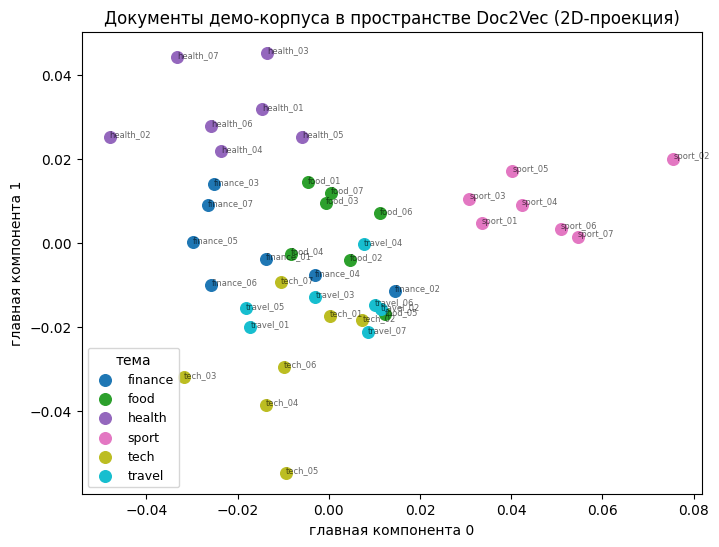

Проекция сохранена: /data/Projects/NLP/lab_3/data/d2v_2d.png


In [14]:
import os, tempfile
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "mplconfig"))
%matplotlib inline

try:
    import matplotlib.pyplot as plt

    X = np.asarray(demo_doc_vectors, dtype="float64")
    Xc = X - X.mean(axis=0)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    proj = Xc @ Vt[:2].T
    print("Проекция:", proj.shape, "| объяснённая дисперсия первых 2 компонент: {:.1%}".format(
        float((s[:2] ** 2).sum() / (s ** 2).sum())))

    labels = sorted(set(demo_topics))
    colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

    plt.figure(figsize=(8, 6))
    for li, lab in enumerate(labels):
        mask = [i for i, t in enumerate(demo_topics) if t == lab]
        plt.scatter(proj[mask, 0], proj[mask, 1], label=lab, color=colors[li], s=70)
    for i, src in enumerate([Path(p).name for p in demo_paths]):
        plt.annotate(src.replace(".txt", ""), (proj[i, 0], proj[i, 1]), fontsize=6, alpha=0.6)
    plt.legend(title="тема", fontsize=9)
    plt.xlabel("главная компонента 0")
    plt.ylabel("главная компонента 1")
    plt.title("Документы демо-корпуса в пространстве Doc2Vec (2D-проекция)")
    out_png = _LAB3 / "data" / "d2v_2d.png"
    plt.savefig(str(out_png), dpi=120, bbox_inches="tight")
    plt.show()
    print("Проекция сохранена:", out_png)
except Exception as exc:
    print("Визуализация недоступна:", repr(exc))

## 13. Пользовательские данные

Анализатор переобучается на произвольном корпусе: достаточно положить текстовые
файлы (по документу на файл) в каталог и вызвать `fit`. Ниже —
«пользовательский» корпус `lab_2/data/custom_corpus/` из 20 документов по 4 темам
(музыка, автомобили, образование, мода), отличным от демо-корпуса.

In [15]:
custom_model_dir = str(_LAB3 / "src" / "models" / "d2v_custom")
custom_analyzer = DocVecAnalyzer(custom_model_dir, method="doc2vec")
custom_stats = custom_analyzer.fit(custom_texts, dim=80, epochs=40,
                                   sources=[Path(p).name for p in custom_paths], seed=42)
print("Обучено на пользовательском корпусе:")
for key in ("method", "n_docs", "n_features", "dim", "epochs"):
    print("  {:10s} = {}".format(key, custom_stats[key]))
print("  {:10s} = {:.2f} c".format("seconds", custom_stats["seconds"]))
print()
print("Словесная семантика пользовательского корпуса:")
for w in ["альбом", "концерт", "двигатель", "передача"]:
    near = custom_analyzer.most_similar(w, top_n=4)
    print(f"  {w:11s} -> " + (", ".join(f"{x}({s:+.2f})" for x, s in near)
                              if near else "нет в словаре (OOV): []")) 
print()
for q in ["Новый альбом и живой концерт популярной группы",
          "Двигатель и коробка передач автомобиля"]:
    print("Запрос:", q)
    for m in custom_analyzer.query(q, top_n=3):
        print(f"  [{m.score:+.3f}] {m.source}: {m.text[:80]}")
    print()

Обучено на пользовательском корпусе:
  method     = doc2vec
  n_docs     = 20
  n_features = 327
  dim        = 80
  epochs     = 40
  seconds    = 0.84 c

Словесная семантика пользовательского корпуса:
  альбом      -> студия(+0.32), уменьшить(+0.31), поклонник(+0.28), год(+0.26)
  концерт     -> инструмент(+0.51), музыкант(+0.50), мелодия(+0.46), сыграть(+0.41)
  двигатель   -> водитель(+0.42), ровно(+0.40), расход(+0.38), идти(+0.35)
  передача    -> нет в словаре (OOV): []

Запрос: Новый альбом и живой концерт популярной группы
  [+0.682] music_03.txt: Рок-группа записала альбом в старой студии с аналоговым пультом. Звук получился 
  [+0.317] music_04.txt: Академический хор готовится к концерту в большом зале. Репетиции идут каждый ден
  [+0.274] music_02.txt: Гитарист выучил новый аккорд и сразу попробовал сыграть любимую мелодию. На урок

Запрос: Двигатель и коробка передач автомобиля
  [+0.648] auto_01.txt: Новый автомобиль получил экономичный двигатель и более жёсткий кузов. Ин

## 14. Масштабный пример на RuReviews (данные `lab_1`)

Тот же конвейер применяется к 2000 отзывам RuReviews (метки тональности не нужны —
метод не требует разметки). Каталог модели `d2v_rureviews` не хранится в git: он
воспроизводится этим ноутбуком.

In [16]:
rr_model_dir = str(_LAB3 / "src" / "models" / "d2v_rureviews")
rr_analyzer = DocVecAnalyzer(rr_model_dir, method="doc2vec")
t0 = time.time()
rr_stats = rr_analyzer.fit(reviews, dim=100, epochs=10, min_count=3, seed=42)
print("RuReviews: n_docs={}, n_features={}, dim={}, epochs={}".format(
    rr_stats["n_docs"], rr_stats["n_features"], rr_stats["dim"], rr_stats["epochs"]))
print("Время обучения: {:.1f} c (полное время ячейки {:.1f} c)".format(
    rr_stats["seconds"], time.time() - t0))
print()
q = "Куртка оказалась мала, пришлось возвращать, но доставка быстрая"
print("Запрос:", q)
for m in rr_analyzer.query(q, top_n=3):
    print(f"  [{m.score:+.3f}] {m.text[:110]}")

RuReviews: n_docs=2000, n_features=1299, dim=100, epochs=10
Время обучения: 13.2 c (полное время ячейки 20.0 c)

Запрос: Куртка оказалась мала, пришлось возвращать, но доставка быстрая
  [+0.590] Хороший материал из которого он изготовлен, а также интересная модель... На мой размер 40рус при росте 173чтоб
  [+0.546] доставка в ХМАО 25 дней-это нормально, но на этом все хорошее и заканчивается!во - первых, цвет: пришел черный
  [+0.537] Пижама радует только разметкой и только до первой стирки!!! Ношу размер s/m рост 175 заказала размер xl штаны 


## 15. Выводы

- Реализованы **shallow-модели** на `numpy`: Word2Vec (skip-gram, SGNS) и
  Doc2Vec (PV-DBOW) с negative sampling; CNN/RNN/LSTM не используются.
- Обе модели обучаются на **тех же канонических токенах** `lab_1`, что и LSA в
  `lab_2`, поэтому сравнение методов корректно.
- **Семантический поиск** по запросу «своими словами» находит документы нужной
  темы; **близость документов** группирует корпус по смыслу; 2D-проекция
  показывает тематические сгустки без разметки.
- На 6 общих запросах Doc2Vec практически совпадает с LSA по теме лучшего
  документа (см. метрики выше): на малом корпусе оба метода улавливают тему,
  но LSA даёт более «уверенные» косинусы, а Doc2Vec — более низкие и иногда
  менее устойчивые.
- Метод масштабируется: обучение на 2000 отзывах RuReviews занимает десятки
  секунд и не требует разметки; модель сохраняется и загружается «из коробки».

### Сравнительная таблица методов

| Критерий | LSA (`lab_2`) | Word2Vec (skip-gram) | Doc2Vec (PV-DBOW) |
|---|---|---|---|
| Представление | TF-IDF + усечённое SVD (латентные темы) | вектор слова по контексту | вектор документа по его словам |
| Метод | матричное разложение (SVD) | shallow-сеть, SGD, negative sampling | shallow-сеть, SGD, negative sampling |
| Размерность | `k` тем (обычно 10–40) | `dim` (60–100) | `dim` (60–100) |
| Обучение | быстрое, детерминированное | медленнее, зависит от эпох | медленнее, зависит от эпох |
| Интерпретируемость | высокая: тема = список терминов | средняя: ближайшие слова | средняя: ближайшие слова/документы |
| Новый документ | fold-in проекцией | mean-pooling векторов слов | fold-in (`infer_vector`) |
| Что лучше | малые корпуса, объяснимость, точные косинусы | семантика слов, аналогии | вектор всего документа, устойчивость к перефразировке |
| Ограничение | не учитывает порядок и контекст | нет вектора документа напрямую | на малом корпусе нестабилен |
